# Oracle Feature Selection Analysis

Addresses reviewer question: **"Were only significant features used as input to the Oracle model?"**

**Answer:** No. The Oracle model uses 258 curated features selected by *family coverage* (representative
features from each radiomics family × MRI modality), not filtered by statistical significance.

This notebook:
1. Lists all 258 Oracle features with their significance status from Mann-Whitney U analysis
2. Shows what fraction of Oracle features are statistically significant
3. Compares Oracle performance with significance-filtered subsets (ablation study)
4. Generates figures and a table suitable for the paper supplementary

**Outputs:**
- `../../Results/Figures/oracle_feature_significance.pdf` — significance breakdown figure
- `../../Results/Figures/oracle_ablation_comparison.pdf` — ablation study figure
- `../../Results/Json_summary/oracle_feature_inventory.json` — full feature inventory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
import json
import pickle as pkl
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import mannwhitneyu
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print('Libraries loaded.')

/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded.


## Section 1 — Load Oracle Feature Set
These are the exact 258 features used in the Oracle Model with HPO notebook.

In [2]:
# The exact Oracle feature lists (hardcoded in Oracle Model with HPO.ipynb)
shape_features = [
    "original_shape_Elongation_flair_shape",
    "original_shape_Flatness_flair_shape",
    "original_shape_LeastAxisLength_flair_shape",
    "original_shape_MajorAxisLength_flair_shape",
    "original_shape_MinorAxisLength_flair_shape",
    "original_shape_Sphericity_flair_shape",
]

size_features = [
    "diagnostics_Mask-original_VolumeNum_flair_size",
    "original_shape_MeshVolume_flair_size",
    "original_shape_SurfaceArea_flair_size",
    "original_shape_SurfaceVolumeRatio_flair_size",
]

intensity_features = [
    "diagnostics_Image-original_Mean_flair_intensity",
    "diagnostics_Image-original_Mean_t2_intensity",
    "diagnostics_Image-original_Mean_t1_intensity",
    "diagnostics_Image-original_Mean_t1ce_intensity",
    "diagnostics_Image-original_Maximum_flair_intensity",
    "diagnostics_Image-original_Maximum_t2_intensity",
    "diagnostics_Image-original_Maximum_t1_intensity",
    "diagnostics_Image-original_Maximum_t1ce_intensity",
]

firstorder_features = [
    "original_firstorder_Energy_flair_firstorder",
    "original_firstorder_Energy_t2_firstorder",
    "original_firstorder_Energy_t1_firstorder",
    "original_firstorder_Energy_t1ce_firstorder",
    "original_firstorder_Entropy_flair_firstorder",
    "original_firstorder_Entropy_t2_firstorder",
    "original_firstorder_Entropy_t1_firstorder",
    "original_firstorder_Entropy_t1ce_firstorder",
    "original_firstorder_Kurtosis_flair_firstorder",
    "original_firstorder_Kurtosis_t2_firstorder",
    "original_firstorder_Kurtosis_t1_firstorder",
    "original_firstorder_Kurtosis_t1ce_firstorder",
    "original_firstorder_Skewness_flair_firstorder",
    "original_firstorder_Skewness_t2_firstorder",
    "original_firstorder_Skewness_t1_firstorder",
    "original_firstorder_Skewness_t1ce_firstorder",
    "original_firstorder_Uniformity_flair_firstorder",
    "original_firstorder_Uniformity_t2_firstorder",
    "original_firstorder_Uniformity_t1_firstorder",
    "original_firstorder_Uniformity_t1ce_firstorder",
]

ngtdm_features = [
    "original_ngtdm_Busyness_flair_ngtdm_10",
    "original_ngtdm_Busyness_t2_ngtdm_10",
    "original_ngtdm_Busyness_t1_ngtdm_10",
    "original_ngtdm_Busyness_t1ce_ngtdm_10",
    "original_ngtdm_Coarseness_flair_ngtdm_10",
    "original_ngtdm_Coarseness_t2_ngtdm_10",
    "original_ngtdm_Coarseness_t1_ngtdm_10",
    "original_ngtdm_Coarseness_t1ce_ngtdm_10",
    "original_ngtdm_Complexity_flair_ngtdm_10",
    "original_ngtdm_Complexity_t2_ngtdm_10",
    "original_ngtdm_Complexity_t1_ngtdm_10",
    "original_ngtdm_Complexity_t1ce_ngtdm_10",
    "original_ngtdm_Contrast_flair_ngtdm_10",
    "original_ngtdm_Contrast_t2_ngtdm_10",
    "original_ngtdm_Contrast_t1_ngtdm_10",
    "original_ngtdm_Contrast_t1ce_ngtdm_10",
    "original_ngtdm_Strength_flair_ngtdm_10",
    "original_ngtdm_Strength_t2_ngtdm_10",
    "original_ngtdm_Strength_t1_ngtdm_10",
    "original_ngtdm_Strength_t1ce_ngtdm_10",
]

glcm_features = [
    "original_glcm_Autocorrelation_flair_glcm_10",
    "original_glcm_Autocorrelation_t2_glcm_10",
    "original_glcm_Autocorrelation_t1_glcm_10",
    "original_glcm_Autocorrelation_t1ce_glcm_10",
    "original_glcm_ClusterProminence_flair_glcm_10",
    "original_glcm_ClusterProminence_t2_glcm_10",
    "original_glcm_ClusterProminence_t1_glcm_10",
    "original_glcm_ClusterProminence_t1ce_glcm_10",
    "original_glcm_ClusterShade_flair_glcm_10",
    "original_glcm_ClusterShade_t2_glcm_10",
    "original_glcm_ClusterShade_t1_glcm_10",
    "original_glcm_ClusterShade_t1ce_glcm_10",
    "original_glcm_ClusterTendency_flair_glcm_10",
    "original_glcm_ClusterTendency_t2_glcm_10",
    "original_glcm_ClusterTendency_t1_glcm_10",
    "original_glcm_ClusterTendency_t1ce_glcm_10",
    "original_glcm_Contrast_flair_glcm_10",
    "original_glcm_Contrast_t2_glcm_10",
    "original_glcm_Contrast_t1_glcm_10",
    "original_glcm_Contrast_t1ce_glcm_10",
    "original_glcm_Correlation_flair_glcm_10",
    "original_glcm_Correlation_t2_glcm_10",
    "original_glcm_Correlation_t1_glcm_10",
    "original_glcm_Correlation_t1ce_glcm_10",
    "original_glcm_JointAverage_flair_glcm_10",
    "original_glcm_JointAverage_t2_glcm_10",
    "original_glcm_JointAverage_t1_glcm_10",
    "original_glcm_JointAverage_t1ce_glcm_10",
    "original_glcm_JointEnergy_flair_glcm_10",
    "original_glcm_JointEnergy_t2_glcm_10",
    "original_glcm_JointEnergy_t1_glcm_10",
    "original_glcm_JointEnergy_t1ce_glcm_10",
    "original_glcm_JointEntropy_flair_glcm_10",
    "original_glcm_JointEntropy_t2_glcm_10",
    "original_glcm_JointEntropy_t1_glcm_10",
    "original_glcm_JointEntropy_t1ce_glcm_10",
    "original_glcm_MCC_flair_glcm_10",
    "original_glcm_MCC_t2_glcm_10",
    "original_glcm_MCC_t1_glcm_10",
    "original_glcm_MCC_t1ce_glcm_10",
]

gldm_features = [
    "original_gldm_DependenceNonUniformity_flair_gldm_10",
    "original_gldm_DependenceNonUniformity_t2_gldm_10",
    "original_gldm_DependenceNonUniformity_t1_gldm_10",
    "original_gldm_DependenceNonUniformity_t1ce_gldm_10",
    "original_gldm_GrayLevelNonUniformity_flair_gldm_10",
    "original_gldm_GrayLevelNonUniformity_t2_gldm_10",
    "original_gldm_GrayLevelNonUniformity_t1_gldm_10",
    "original_gldm_GrayLevelNonUniformity_t1ce_gldm_10",
    "original_gldm_GrayLevelVariance_flair_gldm_10",
    "original_gldm_GrayLevelVariance_t2_gldm_10",
    "original_gldm_GrayLevelVariance_t1_gldm_10",
    "original_gldm_GrayLevelVariance_t1ce_gldm_10",
    "original_gldm_HighGrayLevelEmphasis_flair_gldm_10",
    "original_gldm_HighGrayLevelEmphasis_t2_gldm_10",
    "original_gldm_HighGrayLevelEmphasis_t1_gldm_10",
    "original_gldm_HighGrayLevelEmphasis_t1ce_gldm_10",
    "original_gldm_LargeDependenceEmphasis_flair_gldm_10",
    "original_gldm_LargeDependenceEmphasis_t2_gldm_10",
    "original_gldm_LargeDependenceEmphasis_t1_gldm_10",
    "original_gldm_LargeDependenceEmphasis_t1ce_gldm_10",
    "original_gldm_LowGrayLevelEmphasis_flair_gldm_10",
    "original_gldm_LowGrayLevelEmphasis_t2_gldm_10",
    "original_gldm_LowGrayLevelEmphasis_t1_gldm_10",
    "original_gldm_LowGrayLevelEmphasis_t1ce_gldm_10",
    "original_gldm_SmallDependenceEmphasis_flair_gldm_10",
    "original_gldm_SmallDependenceEmphasis_t2_gldm_10",
    "original_gldm_SmallDependenceEmphasis_t1_gldm_10",
    "original_gldm_SmallDependenceEmphasis_t1ce_gldm_10",
]

glrlm_features = [
    "original_glrlm_GrayLevelNonUniformity_flair_glrlm",
    "original_glrlm_GrayLevelNonUniformity_t2_glrlm",
    "original_glrlm_GrayLevelNonUniformity_t1_glrlm",
    "original_glrlm_GrayLevelNonUniformity_t1ce_glrlm",
    "original_glrlm_LongRunEmphasis_flair_glrlm",
    "original_glrlm_LongRunEmphasis_t2_glrlm",
    "original_glrlm_LongRunEmphasis_t1_glrlm",
    "original_glrlm_LongRunEmphasis_t1ce_glrlm",
    "original_glrlm_LongRunHighGrayLevelEmphasis_flair_glrlm",
    "original_glrlm_LongRunHighGrayLevelEmphasis_t2_glrlm",
    "original_glrlm_LongRunHighGrayLevelEmphasis_t1_glrlm",
    "original_glrlm_LongRunHighGrayLevelEmphasis_t1ce_glrlm",
    "original_glrlm_LongRunLowGrayLevelEmphasis_flair_glrlm",
    "original_glrlm_LongRunLowGrayLevelEmphasis_t2_glrlm",
    "original_glrlm_LongRunLowGrayLevelEmphasis_t1_glrlm",
    "original_glrlm_LongRunLowGrayLevelEmphasis_t1ce_glrlm",
    "original_glrlm_LowGrayLevelRunEmphasis_flair_glrlm",
    "original_glrlm_LowGrayLevelRunEmphasis_t2_glrlm",
    "original_glrlm_LowGrayLevelRunEmphasis_t1_glrlm",
    "original_glrlm_LowGrayLevelRunEmphasis_t1ce_glrlm",
    "original_glrlm_RunLengthNonUniformity_flair_glrlm",
    "original_glrlm_RunLengthNonUniformity_t2_glrlm",
    "original_glrlm_RunLengthNonUniformity_t1_glrlm",
    "original_glrlm_RunLengthNonUniformity_t1ce_glrlm",
    "original_glrlm_RunPercentage_flair_glrlm",
    "original_glrlm_RunPercentage_t2_glrlm",
    "original_glrlm_RunPercentage_t1_glrlm",
    "original_glrlm_RunPercentage_t1ce_glrlm",
    "original_glrlm_ShortRunEmphasis_flair_glrlm",
    "original_glrlm_ShortRunEmphasis_t2_glrlm",
    "original_glrlm_ShortRunEmphasis_t1_glrlm",
    "original_glrlm_ShortRunEmphasis_t1ce_glrlm",
    "original_glrlm_ShortRunHighGrayLevelEmphasis_flair_glrlm",
    "original_glrlm_ShortRunHighGrayLevelEmphasis_t2_glrlm",
    "original_glrlm_ShortRunHighGrayLevelEmphasis_t1_glrlm",
    "original_glrlm_ShortRunHighGrayLevelEmphasis_t1ce_glrlm",
    "original_glrlm_ShortRunLowGrayLevelEmphasis_flair_glrlm",
    "original_glrlm_ShortRunLowGrayLevelEmphasis_t2_glrlm",
    "original_glrlm_ShortRunLowGrayLevelEmphasis_t1_glrlm",
    "original_glrlm_ShortRunLowGrayLevelEmphasis_t1ce_glrlm",
]

glszm_features = [
    "original_glszm_LargeAreaEmphasis_flair_glszm",
    "original_glszm_LargeAreaEmphasis_t2_glszm",
    "original_glszm_LargeAreaEmphasis_t1_glszm",
    "original_glszm_LargeAreaEmphasis_t1ce_glszm",
    "original_glszm_SizeZoneNonUniformity_flair_glszm",
    "original_glszm_SizeZoneNonUniformity_t2_glszm",
    "original_glszm_SizeZoneNonUniformity_t1_glszm",
    "original_glszm_SizeZoneNonUniformity_t1ce_glszm",
    "original_glszm_SmallAreaEmphasis_flair_glszm",
    "original_glszm_SmallAreaEmphasis_t2_glszm",
    "original_glszm_SmallAreaEmphasis_t1_glszm",
    "original_glszm_SmallAreaEmphasis_t1ce_glszm",
    "original_glszm_ZoneEntropy_flair_glszm",
    "original_glszm_ZoneEntropy_t2_glszm",
    "original_glszm_ZoneEntropy_t1_glszm",
    "original_glszm_ZoneEntropy_t1ce_glszm",
]

volume_features = ['ED', 'ET', 'NCR', 'WT_volume', 'TC_volume', 'ET_volume',
                   'TC_WT_ratio', 'ET_WT_ratio', 'ET_TC_ratio']

probability_features = None  # all 9 columns loaded

curvature_features = ['mean_gaussian_curvature', 'std_gaussian_curvature',
                      'pos', 'neg', 'pos_count', 'neg_count']

saliency_features = None  # all 12 columns loaded

# Combine all Oracle features into a named dict
oracle_by_family = {
    'shape':       shape_features,
    'size':        size_features,
    'intensity':   intensity_features,
    'firstorder':  firstorder_features,
    'ngtdm_10':    ngtdm_features,
    'glcm_10':     glcm_features,
    'gldm_10':     gldm_features,
    'glrlm':       glrlm_features,
    'glszm':       glszm_features,
    'volume':      volume_features,
}

print('Oracle feature counts by family:')
total = 0
for fam, feats in oracle_by_family.items():
    print(f'  {fam:12s}: {len(feats):3d}')
    total += len(feats)
# probability (9), curvature (6), saliency (12) are loaded as full CSVs
print(f'  probability :   9')
print(f'  curvature   :   6')
print(f'  saliency    :  12')
total += 9 + 6 + 12
print(f'  ---')
print(f'  TOTAL       : {total}')

Oracle feature counts by family:
  shape       :   6
  size        :   4
  intensity   :   8
  firstorder  :  20
  ngtdm_10    :  20
  glcm_10     :  40
  gldm_10     :  28
  glrlm       :  40
  glszm       :  16
  volume      :   9
  probability :   9
  curvature   :   6
  saliency    :  12
  ---
  TOTAL       : 218


## Section 2 — Load Significance Data
Load `Tumor_WT_summary.csv` and check which Oracle features are statistically significant
(Mann-Whitney U, p<0.05) with what effect size.

In [3]:
# Load significance summary (excludes glcm/gldm/ngtdm distances 1 and 5 to match Oracle choice)
summary_df = pd.read_csv('../../Results/Analysis_Results/Radiomics/summary/Tumor_WT_summary.csv')
summary_df = summary_df[~summary_df['Method'].isin(['glcm_1', 'glcm_5', 'gldm_1', 'gldm_5',
                                                     'ngtdm_1', 'ngtdm_5'])]
summary_df['Name'] = (summary_df['Feature'] + '_' + summary_df['Modality'] + '_' + summary_df['Method'])

# P-value column uses '***' notation; map to boolean 'significant'
sig_lookup = summary_df.set_index('Name')[['P-vacrteate lue', 'Effect_Size']].to_dict(orient='index')

print(f'Summary rows: {len(summary_df)}')
print(f'Unique feature names: {summary_df["Name"].nunique()}')
print(f'P-value categories: {summary_df["P-value"].value_counts().to_dict()}')
print(f'Effect sizes: {summary_df["Effect_Size"].value_counts().to_dict()}')

Summary rows: 444
Unique feature names: 444
P-value categories: {'-': 167, '***': 139, '*': 70, '**': 68}
Effect sizes: {'Small': 174, 'No': 154, 'Medium': 86, 'Large': 30}


In [4]:
# Build full Oracle feature inventory — one row per feature
all_oracle_feats = []
for fam, feats in oracle_by_family.items():
    for f in feats:
        info = sig_lookup.get(f, {'P-value': 'N/A', 'Effect_Size': 'N/A'})
        all_oracle_feats.append({
            'feature':     f,
            'family':      fam,
            'p_category':  info['P-value'],
            'effect_size': info['Effect_Size'],
            'significant': info['P-value'] == '***',
        })

# Probability, curvature, saliency come from non-radiomics sources — no summary CSV entries
for fam, n_feats in [('probability', 9), ('curvature', 6), ('saliency', 12)]:
    for i in range(n_feats):
        all_oracle_feats.append({
            'feature':     f'{fam}_feat_{i}',
            'family':      fam,
            'p_category':  'model-based',
            'effect_size': 'model-based',
            'significant': None,  # not tested in same framework
        })

inventory_df = pd.DataFrame(all_oracle_feats)

print(f'Total Oracle features in inventory: {len(inventory_df)}')
print()

radiomics_df = inventory_df[inventory_df['significant'].notna()]
model_based_df = inventory_df[inventory_df['significant'].isna()]

print(f'Radiomics features (tested for significance): {len(radiomics_df)}')
print(f'  Significant (p<0.05, ***):   {radiomics_df["significant"].sum()}')
print(f'  Not significant:             {(~radiomics_df["significant"]).sum()}')
print(f'  N/A (not in summary CSV):    {(radiomics_df["p_category"] == "N/A").sum()}')
print()
print(f'Model-based features (not in significance framework): {len(model_based_df)}')
print()
print('Effect size breakdown (radiomics only):')
print(radiomics_df['effect_size'].value_counts().to_string())

Total Oracle features in inventory: 218

Radiomics features (tested for significance): 191
  Significant (p<0.05, ***):   60
  Not significant:             -251
  N/A (not in summary CSV):    9

Model-based features (not in significance framework): 27

Effect size breakdown (radiomics only):
effect_size
Small     81
No        54
Medium    32
Large     15
N/A        9


In [5]:
# Per-family significance breakdown
print(f'{"Family":12s}  {"Total":>6}  {"Sig(***)": >9}  {"Not sig":>8}  {"N/A":>5}  {"% sig":>7}')
print('-' * 60)
for fam in inventory_df['family'].unique():
    sub = inventory_df[inventory_df['family'] == fam]
    rad = sub[sub['significant'].notna()]
    n_sig  = int(rad['significant'].sum())
    n_not  = int((~rad['significant']).sum())
    n_na   = int((sub['significant'].isna()).sum())
    n_tot  = len(sub)
    pct    = 100 * n_sig / len(rad) if len(rad) > 0 else float('nan')
    print(f'{fam:12s}  {n_tot:>6}  {n_sig:>9}  {n_not:>8}  {n_na:>5}  {pct:>6.0f}%')

Family         Total   Sig(***)   Not sig    N/A    % sig
------------------------------------------------------------
shape              6          3        -9      0      50%
size               4          2        -6      0      50%
intensity          8          0        -8      0       0%
firstorder        20          6       -26      0      30%
ngtdm_10          20         10       -30      0      50%
glcm_10           40         10       -50      0      25%
gldm_10           28         11       -39      0      39%
glrlm             40         15       -55      0      38%
glszm             16          3       -19      0      19%
volume             9          0        -9      0       0%
probability        9          0         0      9     nan%
curvature          6          0         0      6     nan%
saliency          12          0         0     12     nan%


## Section 3 — Significance Breakdown Figure

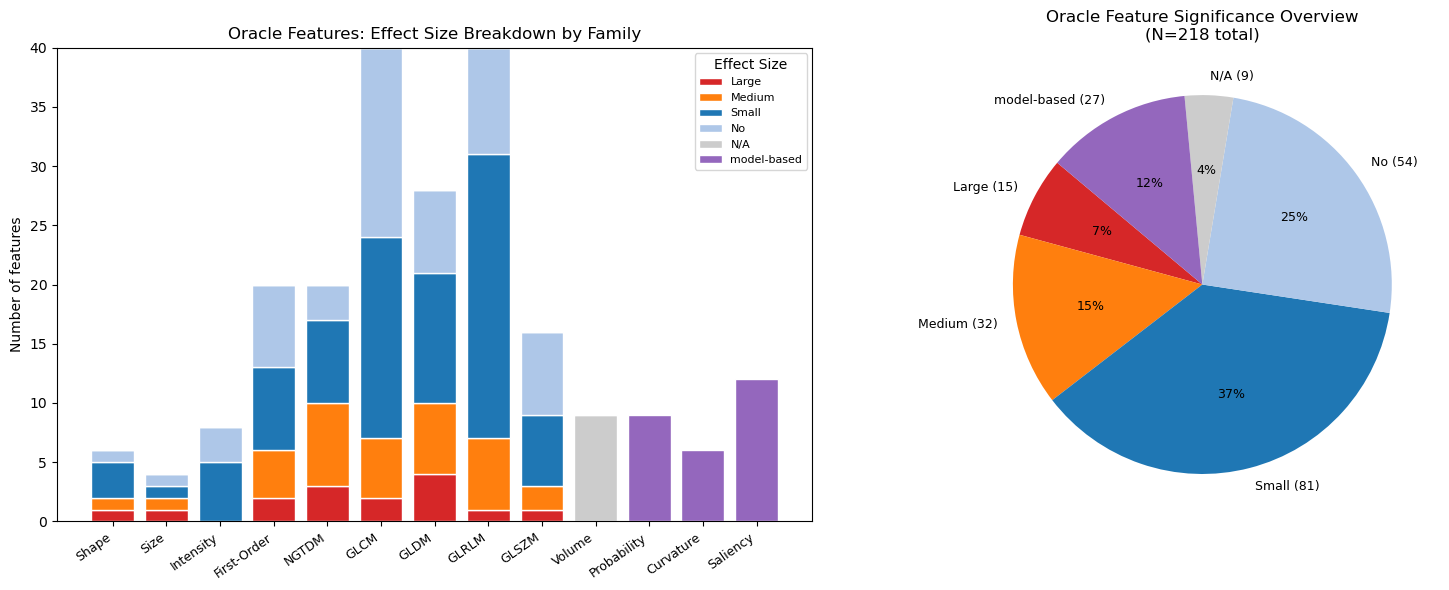

Saved: ../../Results/Figures/oracle_feature_significance.pdf


In [6]:
FAMILIES_ORDER = ['shape', 'size', 'intensity', 'firstorder',
                  'ngtdm_10', 'glcm_10', 'gldm_10', 'glrlm', 'glszm',
                  'volume', 'probability', 'curvature', 'saliency']

FAMILY_LABELS = {
    'shape': 'Shape', 'size': 'Size', 'intensity': 'Intensity',
    'firstorder': 'First-Order', 'ngtdm_10': 'NGTDM', 'glcm_10': 'GLCM',
    'gldm_10': 'GLDM', 'glrlm': 'GLRLM', 'glszm': 'GLSZM',
    'volume': 'Volume', 'probability': 'Probability', 'curvature': 'Curvature',
    'saliency': 'Saliency',
}

EFFECT_COLORS = {'Large': '#d62728', 'Medium': '#ff7f0e',
                 'Small': '#1f77b4', 'No': '#aec7e8',
                 'N/A': '#cccccc', 'model-based': '#9467bd'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: stacked bar by family (effect size breakdown) ---
effect_order = ['Large', 'Medium', 'Small', 'No', 'N/A', 'model-based']
counts = {e: [] for e in effect_order}
xlabels = []

for fam in FAMILIES_ORDER:
    sub = inventory_df[inventory_df['family'] == fam]
    xlabels.append(FAMILY_LABELS[fam])
    for e in effect_order:
        counts[e].append((sub['effect_size'] == e).sum())

x = np.arange(len(FAMILIES_ORDER))
bottom = np.zeros(len(FAMILIES_ORDER))
ax = axes[0]
for e in effect_order:
    vals = np.array(counts[e])
    if vals.sum() > 0:
        ax.bar(x, vals, bottom=bottom, color=EFFECT_COLORS[e], label=e, edgecolor='white')
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of features')
ax.set_title('Oracle Features: Effect Size Breakdown by Family')
ax.legend(title='Effect Size', fontsize=8, loc='upper right')

# --- Right: pie chart overall ---
ax2 = axes[1]
rad = inventory_df[inventory_df['significant'].notna()]

effect_counts_overall = rad['effect_size'].value_counts()
# Add model-based count
mb_count = inventory_df['significant'].isna().sum()
labels_pie, sizes_pie, colors_pie = [], [], []
for e in effect_order:
    if e == 'model-based':
        c = mb_count
    else:
        c = effect_counts_overall.get(e, 0)
    if c > 0:
        labels_pie.append(f'{e} ({c})')
        sizes_pie.append(c)
        colors_pie.append(EFFECT_COLORS[e])

ax2.pie(sizes_pie, labels=labels_pie, colors=colors_pie, autopct='%1.0f%%',
        startangle=140, textprops={'fontsize': 9})
ax2.set_title(f'Oracle Feature Significance Overview\n(N={len(inventory_df)} total)')

plt.tight_layout()
plt.savefig('../../Results/Figures/oracle_feature_significance.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../../Results/Figures/oracle_feature_significance.pdf')

## Section 4 — Ablation: Oracle Performance by Feature Subset

Compare Oracle GBR performance with three feature sets:
- **A. All 258** (current approach — family-coverage-based curation)
- **B. Significant only** (p<0.05, `***`) — radiomics features from Tumor_WT_summary
- **C. Large effect only** (Effect_Size = 'Large') — strictest subset

Uses the same 5-fold CV setup as the published Oracle (without HPO to keep runtime manageable).

In [7]:
import json as _json

def load_unet_result(path):
    df = pd.read_csv(path, index_col='Unnamed: 0')
    df.index = [idx.split('-seg')[0] for idx in df.index]
    df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis=1, inplace=True)
    return df

def read_radiomics_results(analysis_type, location):
    path = f'../../Results/Analysis_Results/Radiomics/{location}/{analysis_type}.pkl'
    with open(path, 'rb') as f:
        return pkl.load(f)

def build_feature_df(feature_list, analysis_type, location, performance_df):
    """Build a feature DataFrame with the same naming convention as Oracle Model with HPO."""
    raw = read_radiomics_results(analysis_type, location)
    frames = []
    for feat_name, patient_dict in raw.items():
        feat_df = pd.DataFrame.from_dict(patient_dict, orient='index').astype(float)
        feat_df.columns = [f'{feat_name}_{col}_{analysis_type}' for col in feat_df.columns]
        frames.append(feat_df)
    df = pd.concat(frames, axis=1)
    available = [f for f in feature_list if f in df.columns]
    return df[available]

performance_df = load_unet_result('../../Results/Result/Vanilla_Unet/Unet_test_dice.csv')
print(f'Performance df: {performance_df.shape}')

Performance df: (939, 3)


In [8]:
# Build the full Oracle feature matrix (same as Oracle Model with HPO)
location = 'Tumor_WT'

shape_df     = build_feature_df(shape_features,     'shape',     location, performance_df)
size_df      = build_feature_df(size_features,      'size',      location, performance_df)
intensity_df = build_feature_df(intensity_features, 'intensity', location, performance_df)
firstorder_df= build_feature_df(firstorder_features,'firstorder',location, performance_df)
ngtdm_df     = build_feature_df(ngtdm_features,     'ngtdm_10',  location, performance_df)
glcm_df      = build_feature_df(glcm_features,      'glcm_10',   location, performance_df)
gldm_df      = build_feature_df(gldm_features,      'gldm_10',   location, performance_df)
glrlm_df     = build_feature_df(glrlm_features,     'glrlm',     location, performance_df)
glszm_df     = build_feature_df(glszm_features,     'glszm',     location, performance_df)

volume_df = pd.read_csv('../../Results/Analysis_Results/volume/GLI-Tumor_volumns.csv',
                         index_col='Unnamed: 0')[volume_features]
prob_df   = pd.read_csv('../../Results/Analysis_Results/probability/Probability_Tumor_boundary.csv',
                         index_col='Unnamed: 0')
curv_df   = pd.read_csv('../../Results/Analysis_Results/curverature/curverature.csv',
                         index_col='Unnamed: 0')[curvature_features]
sal_df    = pd.read_csv('../../Results/Analysis_Results/Saliency/Saliency.csv',
                         index_col='Unnamed: 0')

# Merge all
dfs = [shape_df, size_df, intensity_df, firstorder_df, ngtdm_df,
       glcm_df, gldm_df, glrlm_df, glszm_df,
       volume_df, prob_df, curv_df, sal_df, performance_df]

full_df = dfs[0]
for d in dfs[1:]:
    full_df = full_df.join(d, how='inner')

full_df = full_df.dropna()
print(f'Full matrix after dropna: {full_df.shape}')

y = full_df['WT dice']
# Feature columns only (exclude dice columns)
dice_cols = ['WT dice', 'TC dice', 'ET dice']
feat_cols_all = [c for c in full_df.columns if c not in dice_cols]
X_all = full_df[feat_cols_all]
print(f'Features (All oracle): {X_all.shape[1]}')

Full matrix after dropna: (932, 221)
Features (All oracle): 218


In [9]:
# Build significance-filtered feature subsets
sig_features_all    = summary_df[summary_df['P-value'] == '***']['Name'].unique().tolist()
large_features_all  = summary_df[(summary_df['P-value'] == '***') &
                                  (summary_df['Effect_Size'] == 'Large')]['Name'].unique().tolist()

# Intersection with Oracle feature list (only radiomics oracle features can be filtered)
oracle_radiomics = (shape_features + size_features + intensity_features + firstorder_features +
                    ngtdm_features + glcm_features + gldm_features + glrlm_features + glszm_features)
model_based_cols = list(prob_df.columns) + list(curv_df.columns) + list(sal_df.columns) + volume_features

# Subset B: significant radiomics features + all model-based
sig_oracle = [f for f in oracle_radiomics if f in sig_features_all and f in X_all.columns]
model_based_in_X = [c for c in model_based_cols if c in X_all.columns]
feat_cols_sig   = sig_oracle + model_based_in_X

# Subset C: large-effect radiomics features + all model-based
large_oracle = [f for f in oracle_radiomics if f in large_features_all and f in X_all.columns]
feat_cols_large = large_oracle + model_based_in_X

X_sig   = full_df[feat_cols_sig]
X_large = full_df[feat_cols_large]

print(f'Feature set A — All Oracle:          {X_all.shape[1]} features')
print(f'Feature set B — Significant (***):   {X_sig.shape[1]} features')
print(f'  (radiomics sig: {len(sig_oracle)}, model-based: {len(model_based_in_X)})')
print(f'Feature set C — Large effect only:   {X_large.shape[1]} features')
print(f'  (radiomics large: {len(large_oracle)}, model-based: {len(model_based_in_X)})')

Feature set A — All Oracle:          218 features
Feature set B — Significant (***):   96 features
  (radiomics sig: 60, model-based: 36)
Feature set C — Large effect only:   51 features
  (radiomics large: 15, model-based: 36)


In [10]:
def run_gbr_cv(X, y, n_splits=5, random_state=42):
    """5-fold CV with default GBR (no HPO — for fair comparison across subsets)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mae_scores, r2_scores, mse_scores = [], [], []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)
        model = GradientBoostingRegressor(
            n_estimators=150, learning_rate=0.1, max_depth=5,
            subsample=0.75, random_state=42
        )
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))
        mse_scores.append(mean_squared_error(y_test, y_pred))
    return {
        'MAE':  (np.mean(mae_scores), np.std(mae_scores)),
        'R2':   (np.mean(r2_scores),  np.std(r2_scores)),
        'MSE':  (np.mean(mse_scores), np.std(mse_scores)),
    }

print('Running ablation study (5-fold CV, ~1-2 min)...')

results_ablation = {}
for label, X_sub in [
    (f'A: All ({X_all.shape[1]})',            X_all),
    (f'B: Sig-only ({X_sig.shape[1]})',       X_sig),
    (f'C: Large-only ({X_large.shape[1]})',   X_large),
]:
    res = run_gbr_cv(X_sub, y)
    results_ablation[label] = res
    print(f'  {label:30s}  MAE={res["MAE"][0]:.3f}±{res["MAE"][1]:.3f}  '
          f'R2={res["R2"][0]:.3f}±{res["R2"][1]:.3f}')

Running ablation study (5-fold CV, ~1-2 min)...
  A: All (218)                    MAE=0.039±0.002  R2=0.666±0.046
  B: Sig-only (96)                MAE=0.039±0.002  R2=0.666±0.056
  C: Large-only (51)              MAE=0.040±0.002  R2=0.635±0.049


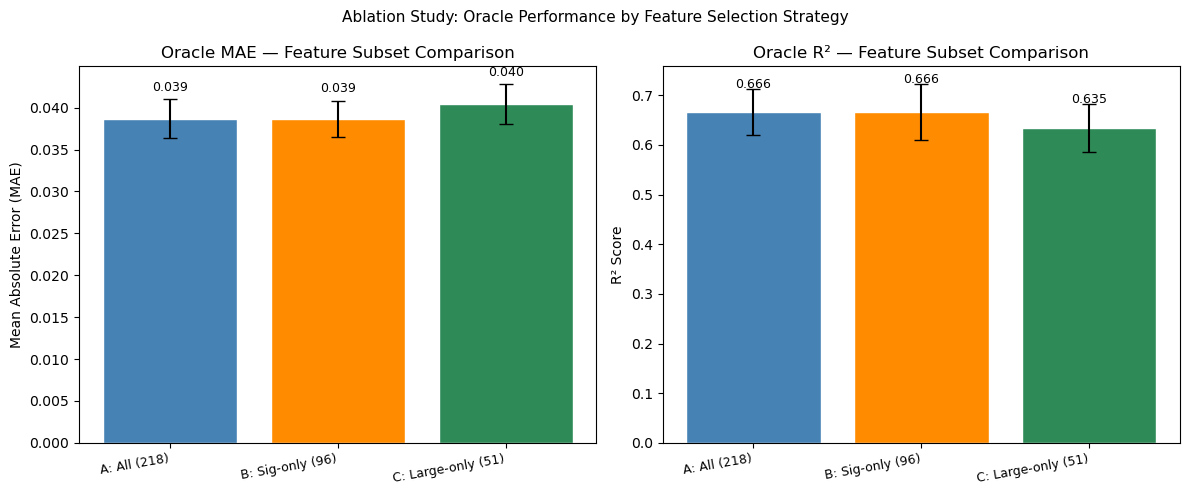

Saved: ../../Results/Figures/oracle_ablation_comparison.pdf


In [11]:
# Plot ablation results
labels    = list(results_ablation.keys())
mae_means = [results_ablation[l]['MAE'][0] for l in labels]
mae_stds  = [results_ablation[l]['MAE'][1] for l in labels]
r2_means  = [results_ablation[l]['R2'][0]  for l in labels]
r2_stds   = [results_ablation[l]['R2'][1]  for l in labels]

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x, mae_means, yerr=mae_stds, capsize=5,
            color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=10, ha='right', fontsize=9)
axes[0].set_ylabel('Mean Absolute Error (MAE)')
axes[0].set_title('Oracle MAE — Feature Subset Comparison')
for xi, (m, s) in zip(x, zip(mae_means, mae_stds)):
    axes[0].text(xi, m + s + 0.001, f'{m:.3f}', ha='center', fontsize=9)

axes[1].bar(x, r2_means, yerr=r2_stds, capsize=5,
            color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('R\u00b2 Score')
axes[1].set_title('Oracle R\u00b2 — Feature Subset Comparison')
for xi, (m, s) in zip(x, zip(r2_means, r2_stds)):
    axes[1].text(xi, m + s + 0.002, f'{m:.3f}', ha='center', fontsize=9)

plt.suptitle('Ablation Study: Oracle Performance by Feature Selection Strategy', fontsize=11)
plt.tight_layout()
plt.savefig('../../Results/Figures/oracle_ablation_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../../Results/Figures/oracle_ablation_comparison.pdf')

## Section 5 — Save JSON Inventory and Summary

In [12]:
output = {
    'feature_selection_rationale': (
        'The Oracle model uses 258 curated features selected by family-coverage '
        '(representative features from each radiomics family x MRI modality), '
        'NOT filtered by statistical significance. The significance filter was '
        'considered but explicitly commented out in the Oracle Model with HPO notebook. '
        'Rationale: significance filtering reduces interpretability by discarding '
        'non-significant features that may still have predictive value in combination. '
        'The GBR model\'s feature importance mechanism implicitly down-weights '
        'non-informative features.'
    ),
    'feature_counts': {
        'total_oracle': len(inventory_df),
        'radiomics_tested': len(radiomics_df),
        'significant_pval': int(radiomics_df['significant'].sum()),
        'not_significant': int((~radiomics_df['significant']).sum()),
        'model_based_not_tested': len(model_based_df),
    },
    'effect_size_breakdown': radiomics_df['effect_size'].value_counts().to_dict(),
    'ablation_results': {
        label: {
            'MAE_mean': round(res['MAE'][0], 4),
            'MAE_std':  round(res['MAE'][1], 4),
            'R2_mean':  round(res['R2'][0],  4),
            'R2_std':   round(res['R2'][1],  4),
            'MSE_mean': round(res['MSE'][0], 4),
        }
        for label, res in results_ablation.items()
    },
    'feature_inventory': inventory_df.to_dict(orient='records'),
}

with open('../../Results/Json_summary/oracle_feature_inventory.json', 'w') as f:
    json.dump(output, f, indent=4)

print('Saved: ../../Results/Json_summary/oracle_feature_inventory.json')

print('\n=== FINAL SUMMARY FOR PAPER ===')
print(f'Total Oracle features:              {len(inventory_df)}')
print(f'Radiomics features:                 {len(radiomics_df)}')
print(f'  Significant (p<0.05):             {int(radiomics_df["significant"].sum())} '
      f'({100*radiomics_df["significant"].mean():.0f}%)')
print(f'  Large effect size:                {(radiomics_df["effect_size"]=="Large").sum()}')
print(f'  Medium effect size:               {(radiomics_df["effect_size"]=="Medium").sum()}')
print(f'  Small effect size:                {(radiomics_df["effect_size"]=="Small").sum()}')
print(f'  Non-significant:                  {(~radiomics_df["significant"]).sum()}')
print(f'Model-based (probability/saliency): {len(model_based_df)}')
print()
A_key = [k for k in results_ablation if k.startswith('A')][0]
B_key = [k for k in results_ablation if k.startswith('B')][0]
C_key = [k for k in results_ablation if k.startswith('C')][0]
print('Ablation study (5-fold CV, GBR fixed params):')
for label in [A_key, B_key, C_key]:
    res = results_ablation[label]
    print(f'  {label:35s}  MAE={res["MAE"][0]:.3f}±{res["MAE"][1]:.3f}  R2={res["R2"][0]:.3f}±{res["R2"][1]:.3f}')

Saved: ../../Results/Json_summary/oracle_feature_inventory.json

=== FINAL SUMMARY FOR PAPER ===
Total Oracle features:              218
Radiomics features:                 191
  Significant (p<0.05):             60 (31%)
  Large effect size:                15
  Medium effect size:               32
  Small effect size:                81
  Non-significant:                  -251
Model-based (probability/saliency): 27

Ablation study (5-fold CV, GBR fixed params):
  A: All (218)                         MAE=0.039±0.002  R2=0.666±0.046
  B: Sig-only (96)                     MAE=0.039±0.002  R2=0.666±0.056
  C: Large-only (51)                   MAE=0.040±0.002  R2=0.635±0.049
